In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

data = load_housing_data()

In [2]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [4]:
import matplotlib.pyplot as plt
import numpy as np

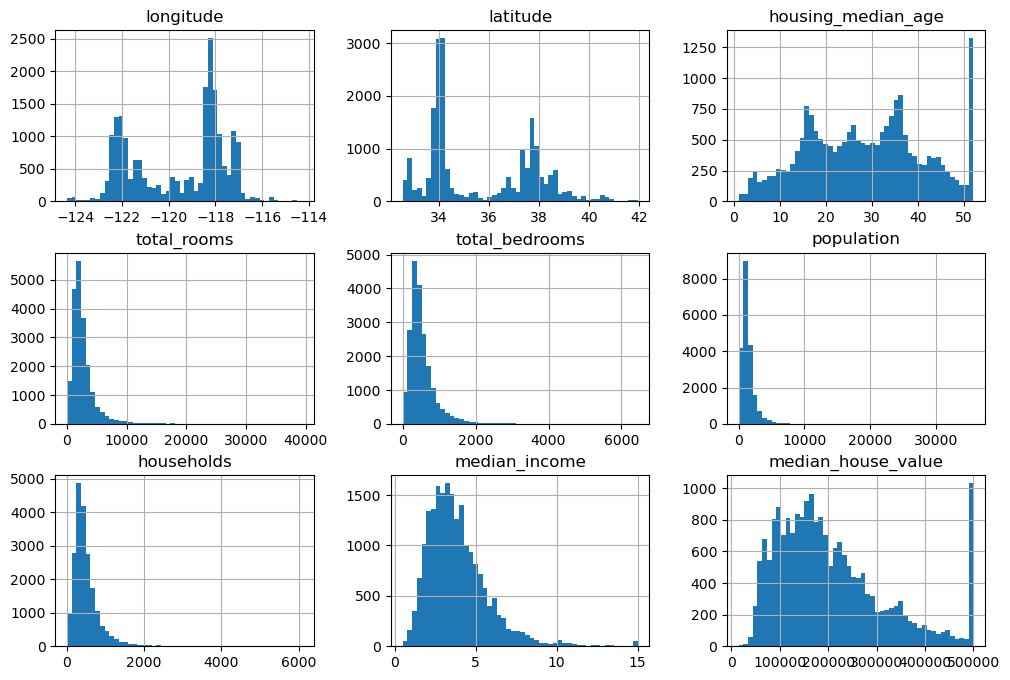

In [5]:
data.hist(bins=50,figsize=(12,8))
plt.show()

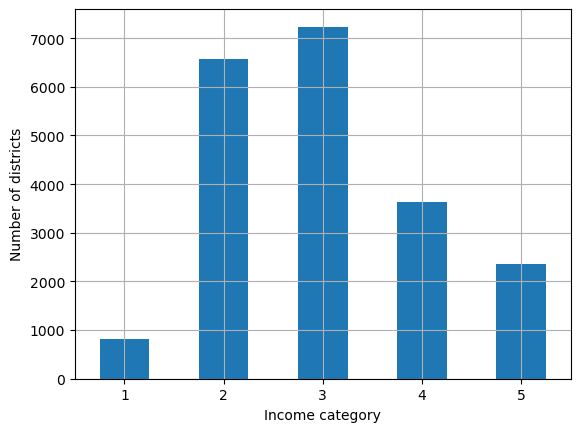

In [6]:
data["income_cat"] = pd.cut(data["median_income"],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

cat_counts = data["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    data, test_size=0.2, stratify=data["income_cat"],
    random_state=42)

In [8]:
strat_test_set["income_cat"].value_counts() #/ len(strat_test_set)

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

In [9]:
df = strat_train_set.copy()

In [10]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN,3


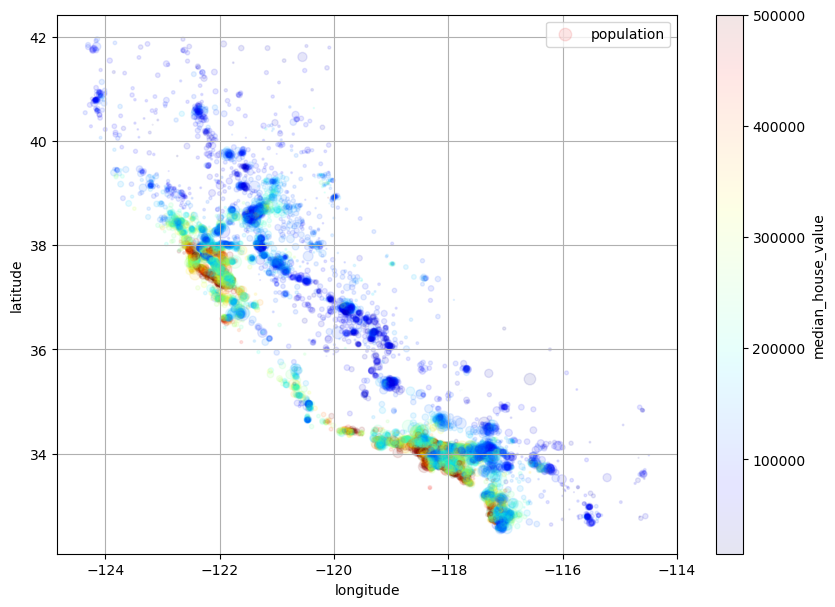

In [11]:
df.plot(kind="scatter" , x="longitude" , y="latitude" , grid=True , alpha=0.1 , s=df["population"]/100,
       label="population",c="median_house_value",cmap="jet",colorbar=True,legend=True,sharex=False,figsize=
       (10,7))
plt.show()

In [12]:
corr_matrix = df.corr(numeric_only=True)

In [13]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

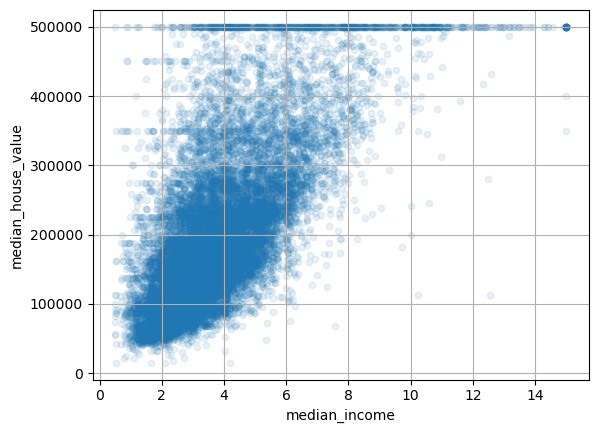

In [14]:
df.plot(kind="scatter",x="median_income",y="median_house_value",alpha=0.1,grid=True)
plt.show()

In [15]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'income_cat'],
      dtype='object')

In [16]:
df["rooms_per_house"] = df["total_rooms"]/df["households"]
df["people_per_house"] = df["population"]/df["households"]
df["bedroom_ratio"] = df["total_bedrooms"]/df["total_rooms"]

In [17]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

In [18]:
X = strat_train_set.drop("median_house_value",axis=1)
y = strat_train_set["median_house_value"].copy()
X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'income_cat'],
      dtype='object')

In [19]:
median = X["total_bedrooms"].median()
X["total_bedrooms"] = X["total_bedrooms"].fillna(median)

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
df_num = df.select_dtypes(include=[np.number])
imputer.fit(df_num)

SimpleImputer(strategy='median')

In [21]:
X = imputer.transform(df_num)

In [22]:
from sklearn.preprocessing import OneHotEncoder

housing_cat = df[["ocean_proximity"]]
one_hot = OneHotEncoder()
housing_cat = one_hot.fit_transform(housing_cat)


In [23]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [24]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(df_num) 

In [25]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(df[["housing_median_age"]],[[35]],gamma=0.1)

In [31]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(df,df_label)

NameError: name 'make_pipeline' is not defined